In [1]:
#IMPORT PACKAGES
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import scipy.stats as stats
import xarray as xr

In [2]:
#LOAD THE DATA
files = [
    "../data/raw/Landsat/LandsatComposite_Zurich_1985.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_1988.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_1991.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_1994.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_1997.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2000.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2003.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2006.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2009.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2012.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2015.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2018.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2021.tif",
    "../data/raw/Landsat/LandsatComposite_Zurich_2024.tif",    
]
years = [1985, 1988, 1991, 1994, 1997, 2000, 2003,
         2006, 2009, 2012, 2015, 2018, 2021, 2024] #assign a year label to every file
times = pd.to_datetime(years, format="%Y") #conevrt them into real datetime objects

In [3]:
#CREATE NDVI AND LST
#the whole workflow in a function  
def process_scene(path):
    ds = xr.open_dataset(path, engine="rasterio")
    """
    Process a single Landsat scene to compute NDVI and Land Surface Temperature (LST).

    Parameters
    ----------
    path : str
        File path to a Landsat GeoTIFF opened with the rasterio engine.
        The dataset is expected to contain:
        - band 3 : Red
        - band 4 : Near-infrared (NIR)
        - band 7 : Thermal infrared (TIR)

    Returns
    -------
    xr.Dataset
        A dataset containing:
        - ndvi : Normalized Difference Vegetation Index
        - lst  : Land Surface Temperature in degrees Celsius

    Processing steps
    ----------------
    1. NDVI is computed as (NIR - Red) / (NIR + Red), clipped to [-1, 1].
    2. Pixel-wise emissivity is estimated from NDVI using a simple NDVI-based
       emissivity model.
    3. LST is derived from the thermal band using emissivity correction
       and converted from Kelvin to Celsius.
    """

    red = ds.band_data.sel(band=3)
    nir = ds.band_data.sel(band=4)
    thermal = ds.band_data.sel(band=7)

    # NDVI
    ndvi = (nir - red) / (nir + red)
    ndvi = ndvi.where((nir + red) != 0)
    ndvi = ndvi.clip(min=-1, max=1)

    # NDVI-based emissivity
    veg_prop = ((ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())) ** 2
    emissivity = 0.004 * veg_prop + 0.986

    # LST
    lambda_ = 11.45e-6 #wavelength of the thermal band (≈ 11.45 µm for Landsat)
    rho = 1.438e-2 #constant derived from Planck's law 

    lst = thermal / (1 + (lambda_ * thermal / rho) * np.log(emissivity)) #thermal = BT
    lst_c = lst - 273.15

    # Return summary stats
    return xr.Dataset({
        "ndvi": ndvi,
        "lst": lst_c
    })

In [4]:
#DATA CUBE
datasets = []

for f, t in zip(files, times):
    ds_scene = process_scene(f)

    ds_scene = ds_scene.expand_dims(time=[t])

    datasets.append(ds_scene)

# build the cube FIRST
ds_cube = xr.concat(datasets, dim="time")

# THEN assign year coordinate
ds_cube = ds_cube.assign_coords(year=("time", years))

#sorted
ds_cube = ds_cube.sortby("time")

# check
ds_cube

<xarray.Dataset> Size: 17MB
Dimensions:      (time: 14, y: 252, x: 297)
Coordinates:
  * time         (time) datetime64[us] 112B 1985-01-01 1988-01-01 ... 2024-01-01
    year         (time) int64 112B 1985 1988 1991 1994 ... 2015 2018 2021 2024
  * y            (y) float64 2kB 5.253e+06 5.253e+06 ... 5.245e+06 5.245e+06
  * x            (x) float64 2kB 4.6e+05 4.6e+05 4.6e+05 ... 4.688e+05 4.689e+05
    spatial_ref  int64 8B 0
    band         int64 8B 7
Data variables:
    ndvi         (time, y, x) float64 8MB 0.7928 0.8029 0.8354 ... 0.5119 0.5834
    lst          (time, y, x) float64 8MB 24.64 24.98 25.26 ... 32.16 32.02

In [5]:
#COMPUTE MEANS FOR ANALYSIS, mean of all pixels for 1 year
mean_lst = ds_cube["lst"].mean(dim=("x", "y"))
mean_ndvi = ds_cube["ndvi"].mean(dim=("x", "y"))

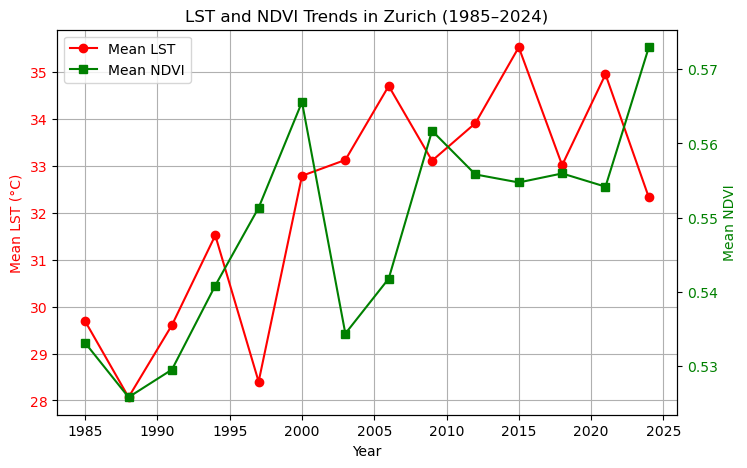

In [6]:
#PLOT LST AGAINST NDVI
fig, ax1 = plt.subplots(figsize=(8,5))

# --- LST axis ---
ax1.plot(years, mean_lst,
         marker="o",
         color="red",
         label="Mean LST")

ax1.set_xlabel("Year")
ax1.set_ylabel("Mean LST (°C)", color="red")
ax1.tick_params(axis='y', labelcolor='red')

# --- NDVI axis ---
ax2 = ax1.twinx()

ax2.plot(years, mean_ndvi,
         marker="s",
         color="green",
         label="Mean NDVI", )

ax2.set_ylabel("Mean NDVI", color="green")
ax2.tick_params(axis='y', labelcolor='green')

# --- Title ---
plt.title("LST and NDVI Trends in Zurich (1985–2024)")

# --- Combined legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2,
           labels1 + labels2,
           loc="upper left")

ax1.grid(True)
plt.savefig("../outputs/LST_NDVI_trends_lineplot.png", dpi=300, bbox_inches="tight")
plt.show()

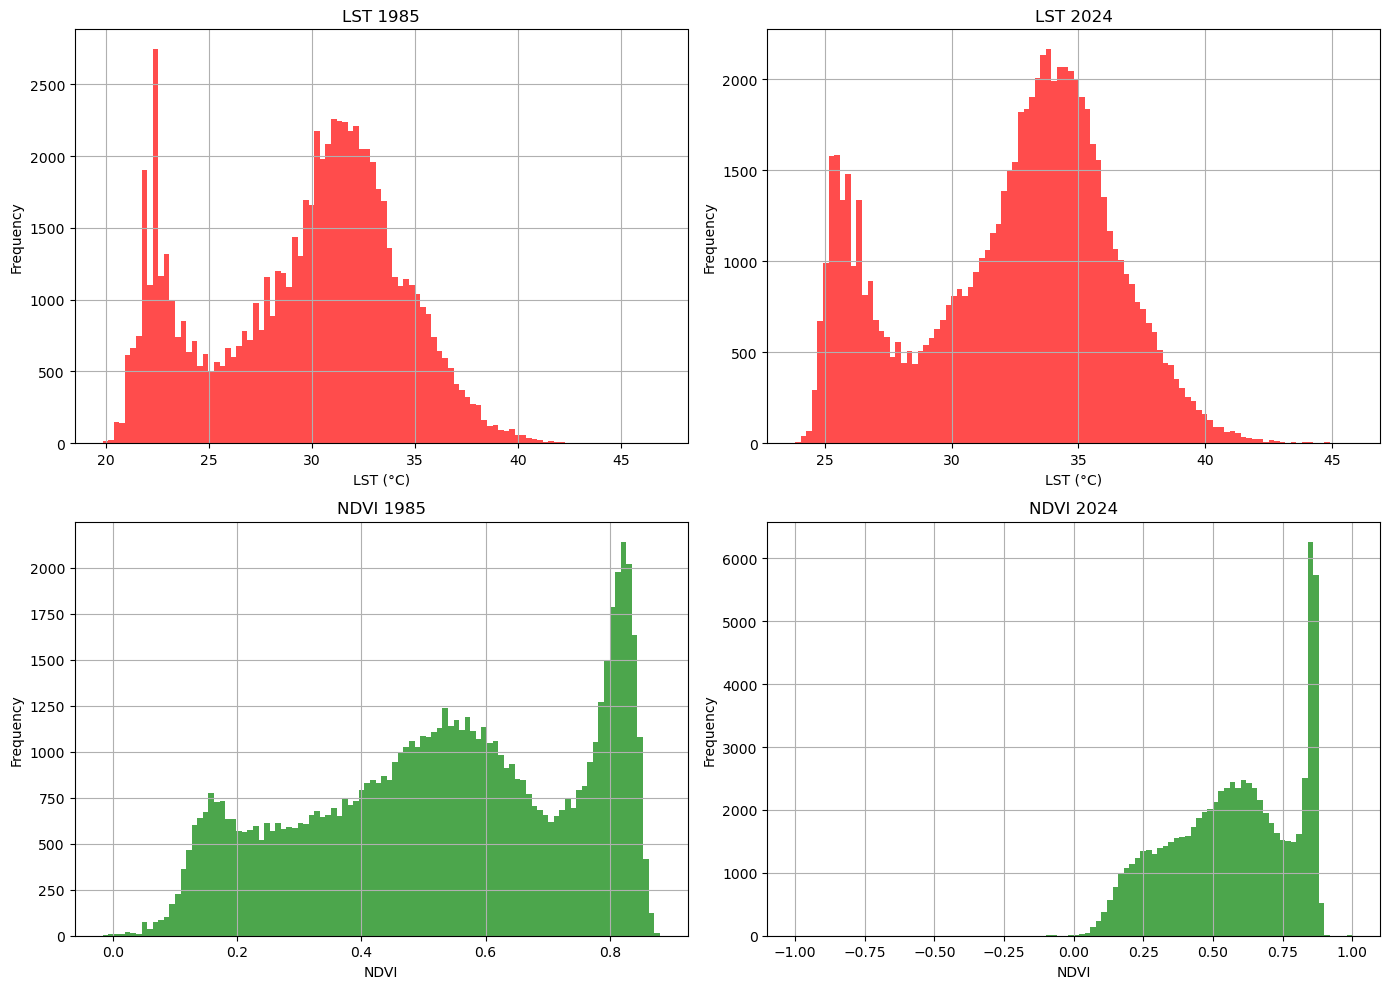

In [7]:
#HISTOGRAM FOR LST, NDVI (each 1985 and 2024)
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# --- LST 1985 ---
ax[0, 0].hist(
    ds_cube["lst"].sel(time="1985-01-01").values.flatten(),
    bins=100,
    color="red",
    alpha=0.7
)
ax[0, 0].set_title("LST 1985")
ax[0, 0].set_xlabel("LST (°C)")
ax[0, 0].set_ylabel("Frequency")
ax[0, 0].grid(True)

# --- LST 2024 ---
ax[0, 1].hist(
    ds_cube["lst"].sel(time="2024-01-01").values.flatten(),
    bins=100,
    color="red",
    alpha=0.7
)
ax[0, 1].set_title("LST 2024")
ax[0, 1].set_xlabel("LST (°C)")
ax[0, 1].set_ylabel("Frequency")
ax[0, 1].grid(True)

# --- NDVI 1985 ---
ax[1, 0].hist(
    ds_cube["ndvi"].sel(time="1985-01-01").values.flatten(),
    bins=100,
    color="green",
    alpha=0.7
)
ax[1, 0].set_title("NDVI 1985")
ax[1, 0].set_xlabel("NDVI")
ax[1, 0].set_ylabel("Frequency")
ax[1, 0].grid(True)

# --- NDVI 2024 ---
ax[1, 1].hist(
    ds_cube["ndvi"].sel(time="2024-01-01").values.flatten(),
    bins=100,
    color="green",
    alpha=0.7
)
ax[1, 1].set_title("NDVI 2024")
ax[1, 1].set_xlabel("NDVI")
ax[1, 1].set_ylabel("Frequency")
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()

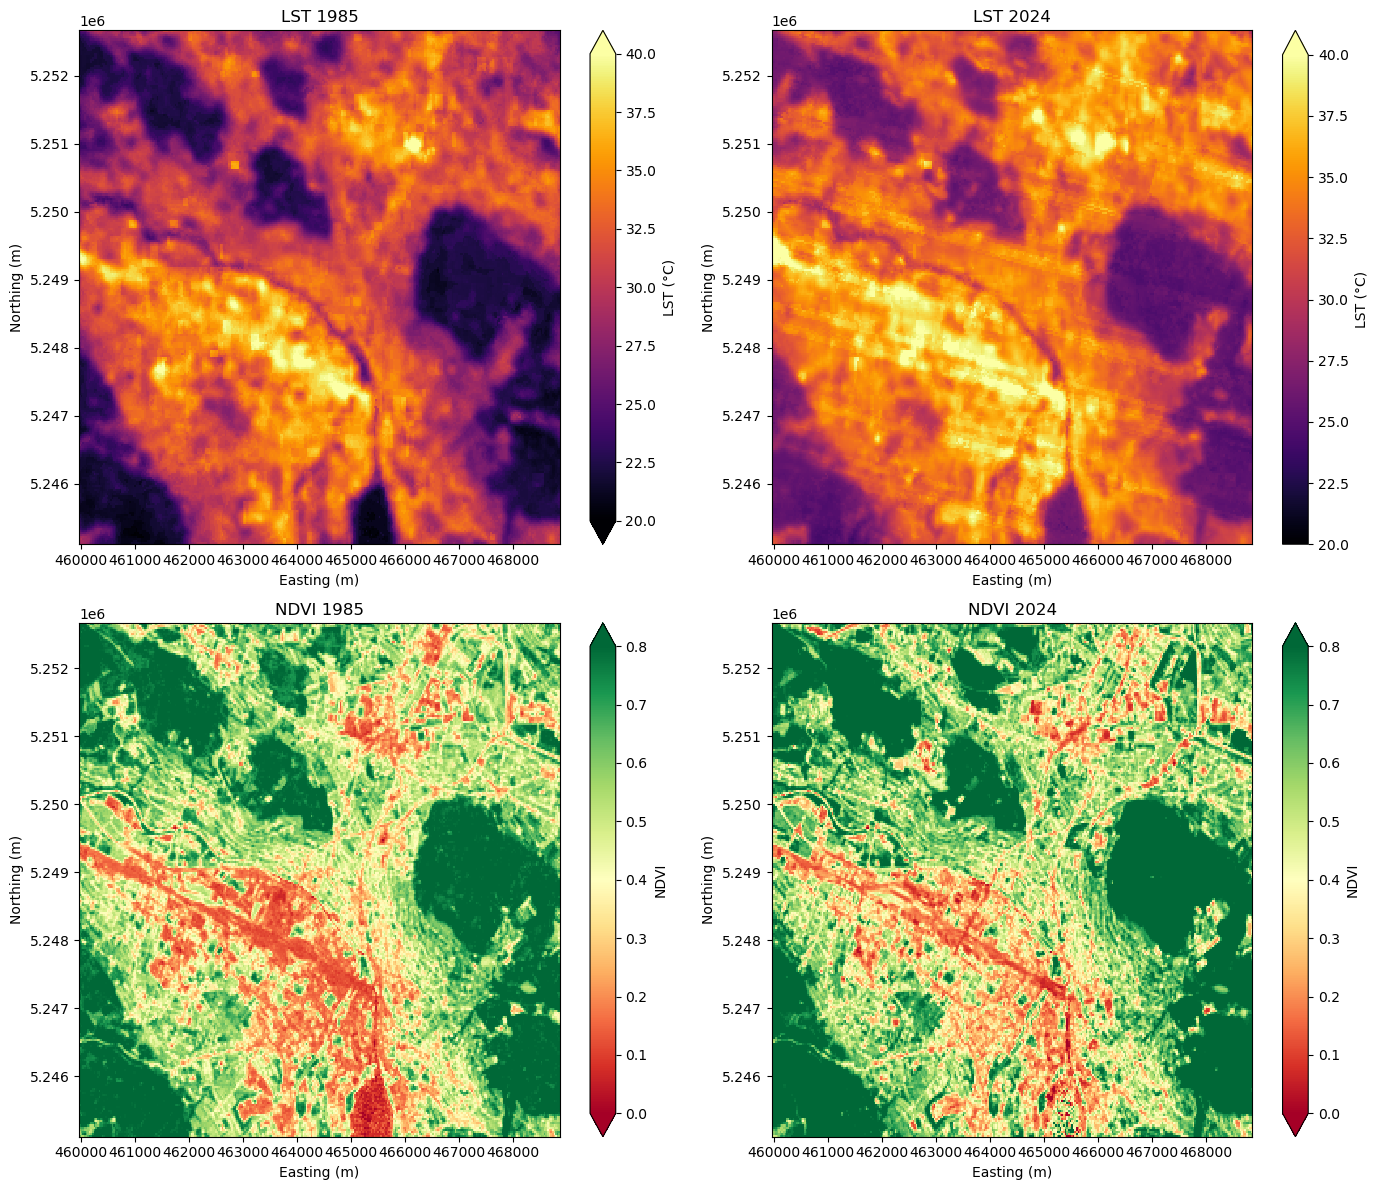

In [8]:
#VISUALIZATION OF LST, NDVI (each 1985 and 2024)
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

# --- LST 1985 ---
m1 = ds_cube["lst"].sel(time="1985-01-01").plot(
    ax=ax[0, 0],
    vmin=20, vmax=40,
    cmap="inferno"
)
ax[0, 0].set_title("LST 1985")
ax[0, 0].set_xlabel("Easting (m)")
ax[0, 0].set_ylabel("Northing (m)")
m1.colorbar.set_label("LST (°C)")

# --- LST 2024 ---
m2 = ds_cube["lst"].sel(time="2024-01-01").plot(
    ax=ax[0, 1],
    vmin=20, vmax=40,
    cmap="inferno"
)
ax[0, 1].set_title("LST 2024")
ax[0, 1].set_xlabel("Easting (m)")
ax[0, 1].set_ylabel("Northing (m)")
m2.colorbar.set_label("LST (°C)")

# --- NDVI 1985 ---
m3 = ds_cube["ndvi"].sel(time="1985-01-01").plot(
    ax=ax[1, 0],
    vmin=0, vmax=0.8,
    cmap="RdYlGn"
)
ax[1, 0].set_title("NDVI 1985")
ax[1, 0].set_xlabel("Easting (m)")
ax[1, 0].set_ylabel("Northing (m)")
m3.colorbar.set_label("NDVI")

# --- NDVI 2024 ---
m4 = ds_cube["ndvi"].sel(time="2024-01-01").plot(
    ax=ax[1, 1],
    vmin=0, vmax=0.8,
    cmap="RdYlGn"
)
ax[1, 1].set_title("NDVI 2024")
ax[1, 1].set_xlabel("Easting (m)")
ax[1, 1].set_ylabel("Northing (m)")
m4.colorbar.set_label("NDVI")

plt.tight_layout()
plt.savefig("../outputs/LST_NDVI_85_24.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# LST CHANGE
lst_1985 = ds_cube["lst"].sel(time="1985-01-01")
lst_2024 = ds_cube["lst"].sel(time="2024-01-01")

lst_change = lst_2024 - lst_1985

# NDVI CHANGE
ndvi_1985 = ds_cube["ndvi"].sel(time="1985-01-01")
ndvi_2024 = ds_cube["ndvi"].sel(time="2024-01-01")

ndvi_change = ndvi_2024 - ndvi_1985

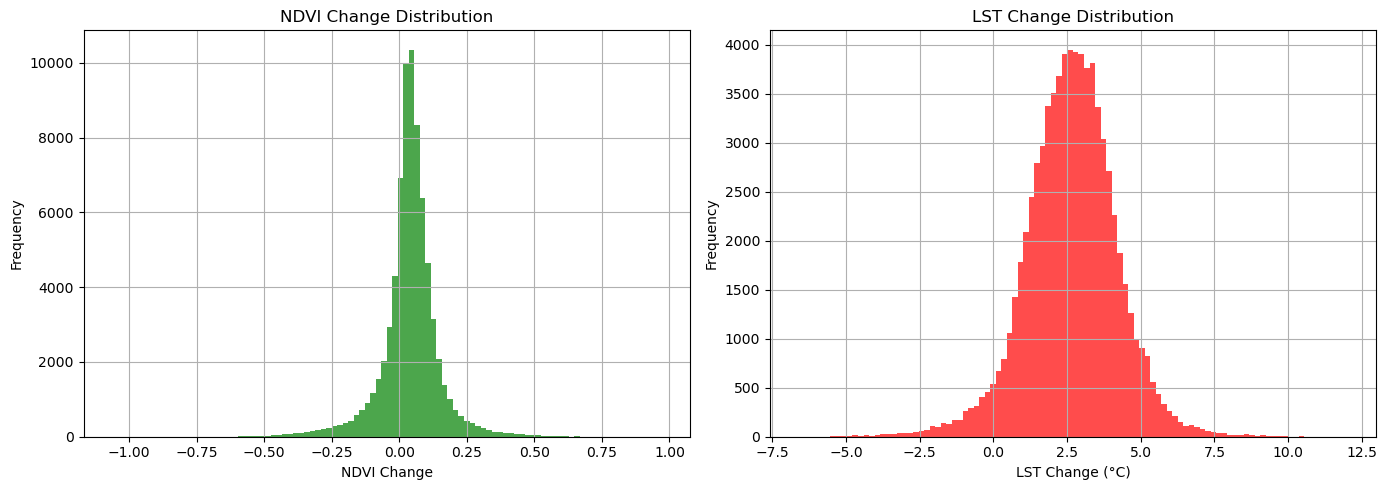

In [11]:
#HISTOGRAM FOR LST-, NDVI CHANGE
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- NDVI Change Histogram ---
ax[0].hist(
    ndvi_change.values.flatten(),
    bins=100,
    color="green",
    alpha=0.7
)
ax[0].set_title("NDVI Change Distribution")
ax[0].set_xlabel("NDVI Change")
ax[0].set_ylabel("Frequency")
ax[0].grid(True)

# --- LST Change Histogram ---
ax[1].hist(
    lst_change.values.flatten(),
    bins=100,
    color="red",
    alpha=0.7
)
ax[1].set_title("LST Change Distribution")
ax[1].set_xlabel("LST Change (°C)")
ax[1].set_ylabel("Frequency")
ax[1].grid(True)

plt.tight_layout()
plt.show()

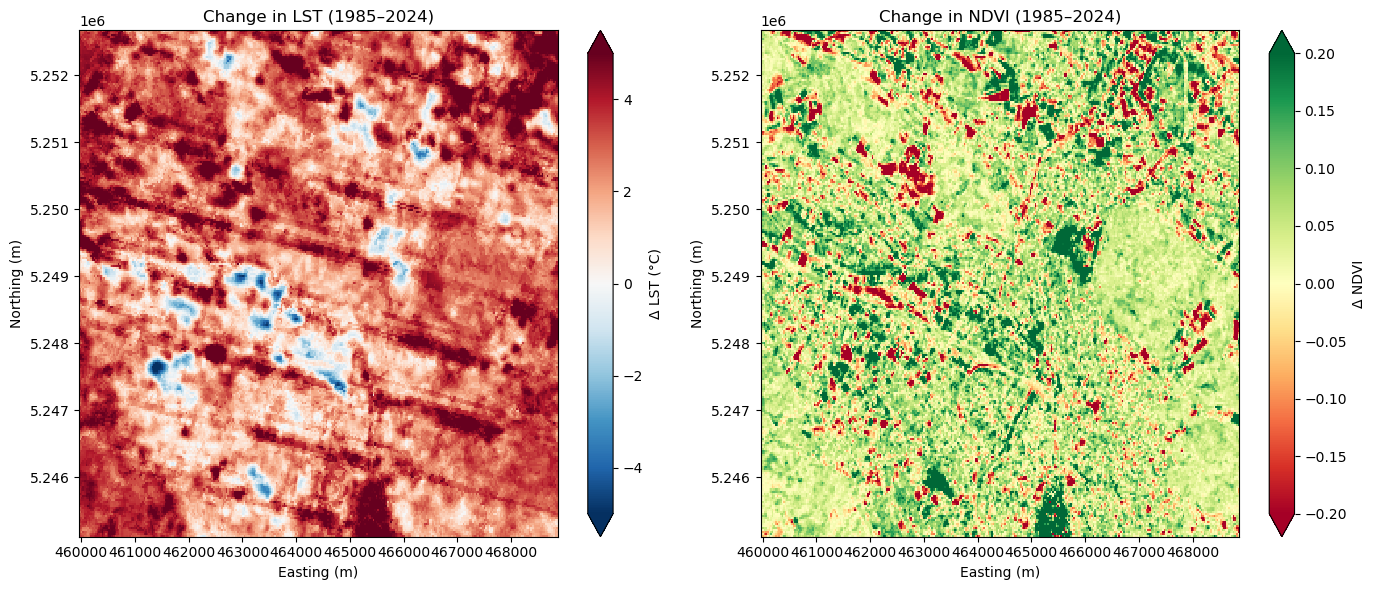

In [12]:
#VISUALIZATION OF LST-, NDVI CHANGE
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- LST Change ---
m1 = lst_change.plot(
    ax=ax[0],
    cmap="RdBu_r",
    vmin=-5, vmax=5
)
ax[0].set_title("Change in LST (1985–2024)")
ax[0].set_xlabel("Easting (m)")
ax[0].set_ylabel("Northing (m)")
m1.colorbar.set_label("Δ LST (°C)")

# --- NDVI Change ---
m2 = ndvi_change.plot(
    ax=ax[1],
    cmap="RdYlGn",
    vmin=-0.2, vmax=0.2
)
ax[1].set_title("Change in NDVI (1985–2024)")
ax[1].set_xlabel("Easting (m)")
ax[1].set_ylabel("Northing (m)")
m2.colorbar.set_label("Δ NDVI")

plt.tight_layout()
plt.savefig("../outputs/LST_NDVI_change.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
#COMPUTE LINEAR TREND LST
# Fit a linear trend across the time dimension for every pixel globally
linear_trend_lst = ds_cube.lst.polyfit(dim="time", deg=1)

# Extract just the slope (coefficient of degree 1) for our trend map
slope_lst = linear_trend_lst.polyfit_coefficients.sel(degree=1)

ns_per_year = 1e9 * 60 * 60 * 24 * 365.25

# Convert the slope to degrees per year
slope_per_year_lst = slope_lst * ns_per_year

# Multiply by 10 to get the climate standard: degrees per decade
slope_per_decade_lst = slope_per_year_lst * 10


#COMPUTE LINEAR TREND NDVI
# Fit a linear trend across the time dimension for every pixel globally
linear_trend_ndvi = ds_cube.ndvi.polyfit(dim="time", deg=1)

# Extract just the slope (coefficient of degree 1) for our trend map
slope_ndvi = linear_trend_ndvi.polyfit_coefficients.sel(degree=1)

# Define the number of nanoseconds in a standard year
ns_per_year = 1e9 * 60 * 60 * 24 * 365.25

# Convert the slope to degrees per year
slope_per_year_ndvi = slope_ndvi * ns_per_year

# Multiply by 10 to get the climate standard: degrees per decade
slope_per_decade_ndvi = slope_per_year_ndvi * 10

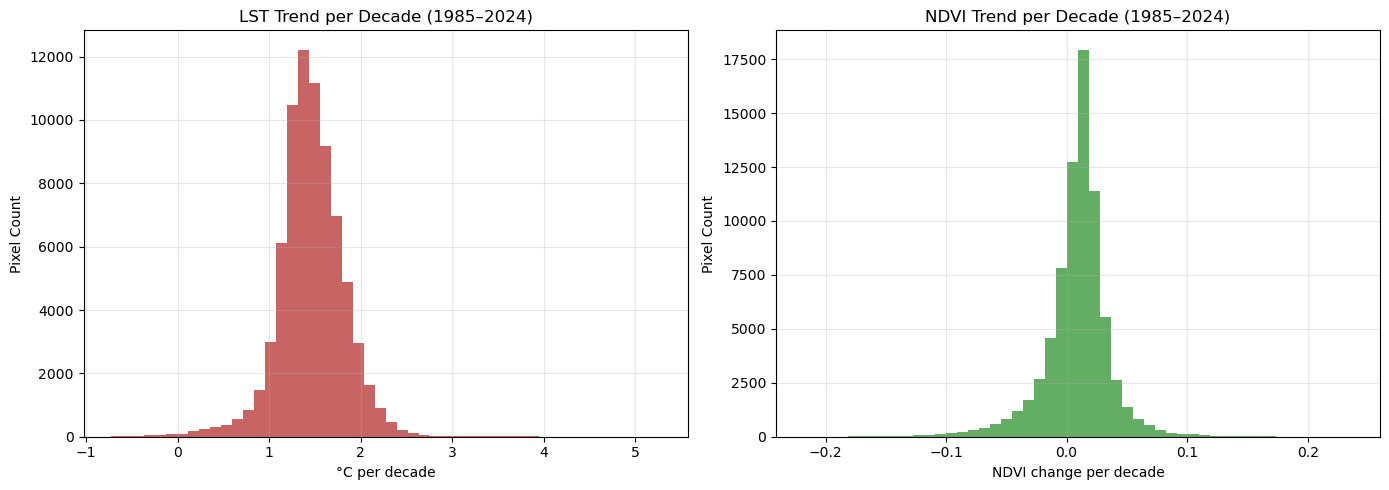

In [14]:
# Extract arrays
lst_trend = slope_per_decade_lst.values.flatten()
ndvi_trend = slope_per_decade_ndvi.values.flatten()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LST histogram ---
axes[0].hist(lst_trend, bins=50, color="firebrick", alpha=0.7)
axes[0].set_title("LST Trend per Decade (1985–2024)")
axes[0].set_xlabel("°C per decade")
axes[0].set_ylabel("Pixel Count")
axes[0].grid(alpha=0.3)

# --- NDVI histogram ---
axes[1].hist(ndvi_trend, bins=50, color="forestgreen", alpha=0.7)
axes[1].set_title("NDVI Trend per Decade (1985–2024)")
axes[1].set_xlabel("NDVI change per decade")
axes[1].set_ylabel("Pixel Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


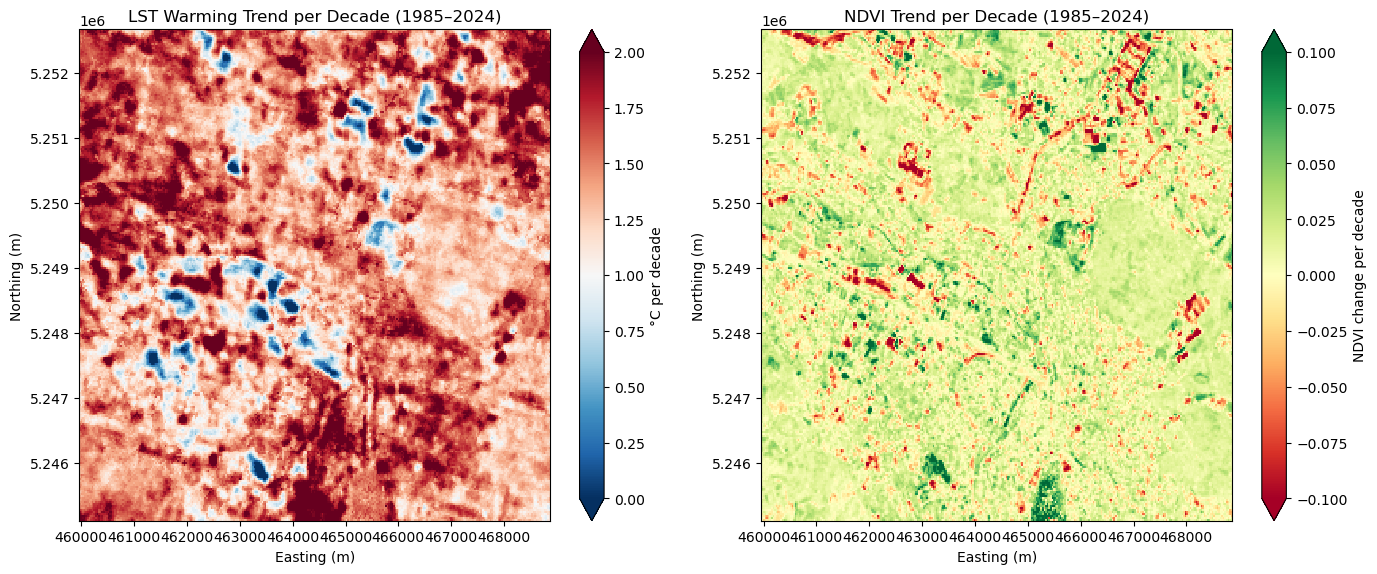

In [15]:
#VISUALIZE LST-, NDVI-TRENDS 
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- LST Trend per Decade ---
m1 = slope_per_decade_lst.plot(
    ax=ax[0],
    cmap="RdBu_r",
    vmin = 0, vmax =2,
    robust=True
)
ax[0].set_title("LST Warming Trend per Decade (1985–2024)")
m1.colorbar.set_label("°C per decade")
m1.axes.set_ylabel("Northing (m)")
m1.axes.set_xlabel("Easting (m)")

# --- NDVI Trend per Decade ---
m2 = slope_per_decade_ndvi.plot(
    ax=ax[1],
    cmap="RdYlGn",
    vmin = -0.1, vmax = 0.1,
    robust=True
)
ax[1].set_title("NDVI Trend per Decade (1985–2024)")
m2.colorbar.set_label("NDVI change per decade")
m2.axes.set_ylabel("Northing (m)")
m2.axes.set_xlabel("Easting (m)")

plt.tight_layout()
plt.savefig("../outputs/LST_NDVI_trendperdec.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
#CREATE A CORRELATION MAP
corr_map = xr.corr(
    ds_cube["ndvi"],
    ds_cube["lst"],
    dim="time"
)

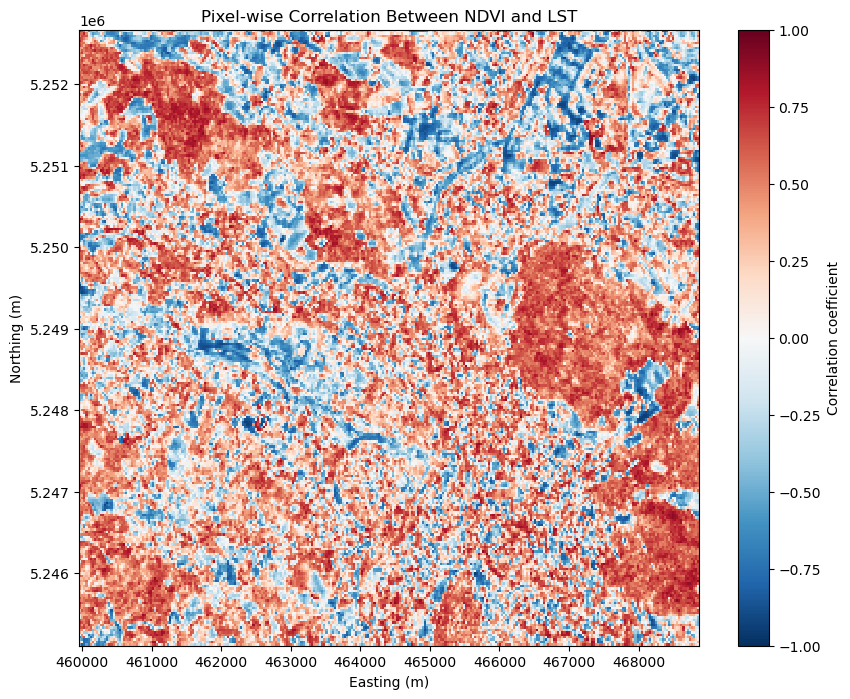

In [17]:
#VISUALIZE CORRELATION MAP
m = corr_map.plot(
    figsize=(10,8),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.title("Pixel-wise Correlation Between NDVI and LST")
m.colorbar.set_label("Correlation coefficient")
m.axes.set_xlabel("Easting (m)")
m.axes.set_ylabel("Northing (m)")
plt.savefig("../outputs/correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
#TEST FOR SIGNIFICANCE 
# number of time steps
n = ds_cube.sizes["time"]

# correlation map 
corr = corr_map

# compute t-statistic for each pixel
t = corr * np.sqrt((n - 2) / (1 - corr**2))

# p-value (two-tailed)
p = stats.t.sf(np.abs(t), df=n-2) * 2

# significance mask (p < 0.05)
sig_mask = p < 0.05

# apply mask: keep only significant correlations
corr_sig = corr.where(sig_mask)

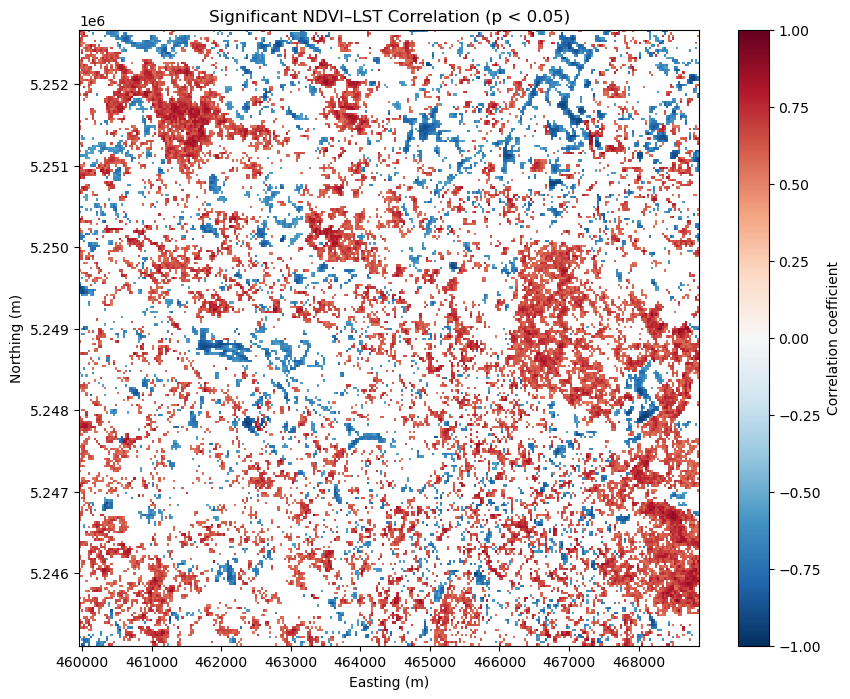

In [19]:
#VISUALIZE SIGNIFICANCE MASK
fig, ax = plt.subplots(figsize=(10, 8))

m = corr_sig.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-1, vmax=1
)

ax.set_title("Significant NDVI–LST Correlation (p < 0.05)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
m.colorbar.set_label("Correlation coefficient")
plt.savefig("../outputs/sign_correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
#CORRELATION PER YEAR 
# extract all years from the datacube
years = ds_cube.time.dt.year.values

results = []

for year in years:
    ds_year = ds_cube.sel(time=str(year))

    ndvi = ds_year["ndvi"].values.flatten()
    lst = ds_year["lst"].values.flatten()

    # compute correlation
    r = np.corrcoef(ndvi, lst)[0, 1]
    r2 = r**2

    results.append([year, r, r2])

# convert to DataFrame
df_corr = pd.DataFrame(results, columns=["Year", "r", "R²"])
df_corr

,Year,r,R²
0,1985,-0.804041,0.646482
1,1988,-0.700585,0.490820
2,1991,-0.810206,0.656434
3,1994,-0.789530,0.623357
4,1997,-0.789684,0.623601
5,2000,-0.806677,0.650728
6,2003,-0.817196,0.667809
7,2006,-0.770604,0.593831
8,2009,-0.812933,0.660860
9,2012,-0.796979,0.635175


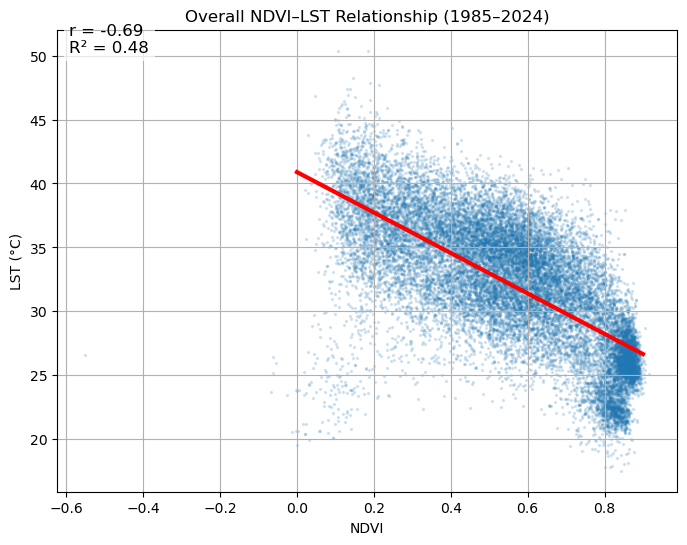

In [21]:
#OVERALL CORRELATION (all years combined)
# flatten all years
ndvi = ds_cube["ndvi"].values.flatten()
lst = ds_cube["lst"].values.flatten()

# subsample for plotting
idx = np.random.choice(len(ndvi), size=20000, replace=False)
x = ndvi[idx]
y = lst[idx]

# regression
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(0, 0.9, 100)
y_line = slope * x_line + intercept

# correlation
corr = np.corrcoef(x, y)[0, 1]
r2 = corr**2

# plot
plt.figure(figsize=(8,6))
plt.scatter(x, y, s=2, alpha=0.15)
plt.plot(x_line, y_line, color="red", linewidth=3)

plt.xlabel("NDVI")
plt.ylabel("LST (°C)")
plt.title("Overall NDVI–LST Relationship (1985–2024)")

plt.text(
    0.02, 0.95,
    f"r = {corr:.2f}\nR² = {r2:.2f}", #R²: NDVI expalins 48% of LST variation
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

plt.grid(True)
plt.savefig("../outputs/scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()